# K-Means Clustering

In [22]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import time  # Added for execution time tracking

In [23]:
# Load the dataset and prepare numeric features for clustering
df = pd.read_csv('../data/processed/finalclusteringdataset.csv')
X = df[['trip_frequency','average_booking_value','destination_diversity','session_duration','search_behavior']]
start_time = time.time()  # Start timing

In [24]:
# Train–Test Split 
from sklearn.model_selection import train_test_split
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
X_train = train_df[['trip_frequency','average_booking_value','destination_diversity','session_duration','search_behavior']]
X_test = test_df[['trip_frequency','average_booking_value','destination_diversity','session_duration','search_behavior']]


In [25]:
wcss = []
silhouette_scores = []
k_range = range(2, 11)
SAMPLE_SIZE = 10000  

for k in k_range:
    kmeans_tmp = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_tmp.fit(X)
    wcss.append(kmeans_tmp.inertia_)
    # Sample for silhouette calculation
    sample_idx = np.random.choice(len(X), size=min(SAMPLE_SIZE, len(X)), replace=False)
    s = silhouette_score(X.iloc[sample_idx], kmeans_tmp.labels_[sample_idx])
    silhouette_scores.append(s)

In [26]:
# Compute optimal k using hybrid approach
from kneed import KneeLocator

# Step 1: k with maximum silhouette score
k_silhouette = k_range[np.nanargmax(silhouette_scores)]
# Step 2: k from elbow method
kl = KneeLocator(k_range, wcss, curve="convex", direction="decreasing")
k_elbow = kl.elbow
# Step 3: Pick optimal k (hybrid)
if k_elbow is not None:
    silhouette_at_k_elbow = silhouette_scores[k_range.index(k_elbow)]
    if not np.isnan(silhouette_at_k_elbow) and silhouette_at_k_elbow > 0.25:
        optimal_k = k_elbow 
    else:
        optimal_k = k_silhouette 
else:
    optimal_k = k_silhouette

In [27]:
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
cluster_labels = kmeans.fit_predict(X)

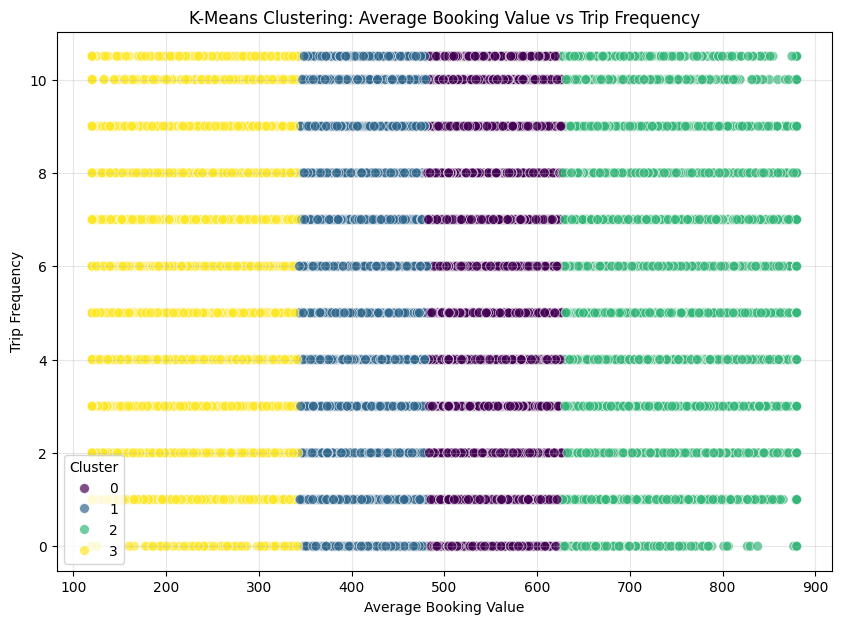

In [28]:
# Cluster Scatter Plot: Average_Booking_Value vs Trip_Frequency
plt.figure(figsize=(10, 7))
sns.scatterplot(data=df.assign(Cluster=cluster_labels),
                x='average_booking_value', y='trip_frequency',
                hue='Cluster', palette='viridis', s=50, alpha=0.7)
plt.title('K-Means Clustering: Average Booking Value vs Trip Frequency')
plt.xlabel('Average Booking Value')
plt.ylabel('Trip Frequency')
plt.legend(title='Cluster')
plt.grid(True, alpha=0.3)
plt.show()

In [29]:
# Cluster distribution
unique, counts = np.unique(cluster_labels, return_counts=True)

c:\Users\vansh\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


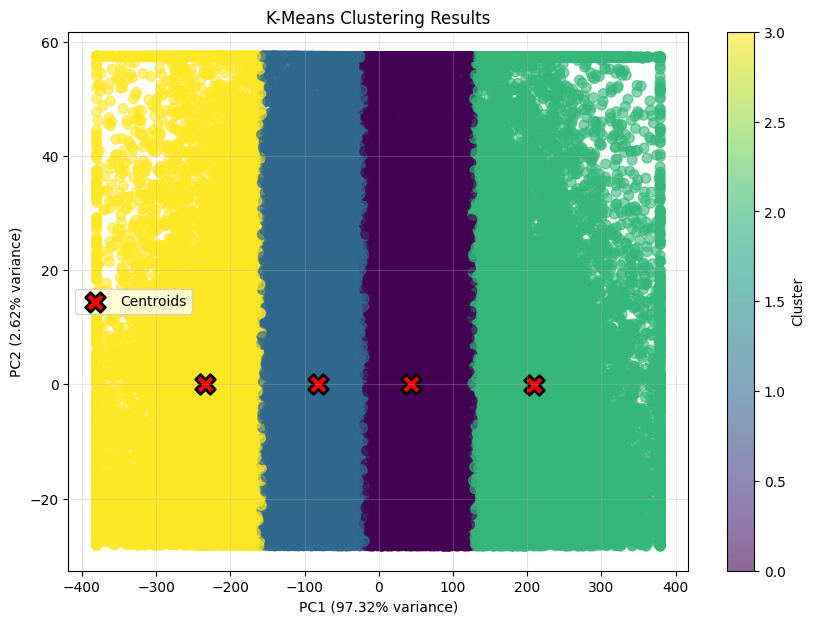

In [30]:
# Visualize clusters 
from sklearn.decomposition import PCA

# Reduce to 2D for visualization
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

plt.figure(figsize=(10, 7))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap='viridis', s=50, alpha=0.6)
# Project cluster centers into PCA space
centers_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centers_pca[:, 0], centers_pca[:, 1], c='red', marker='X', s=200, edgecolors='black', linewidth=2, label='Centroids')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} variance)')
plt.title('K-Means Clustering Results')
plt.colorbar(scatter, label='Cluster')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [31]:
# Calculate metrics before saving
end_time = time.time()
execution_time = end_time - start_time
n_clusters = len(unique)
sample_idx = np.random.choice(len(X), size=min(10000, len(X)), replace=False)
sil_score = silhouette_score(X.iloc[sample_idx], cluster_labels[sample_idx])
# Print summary metrics
print(f'Number of Clusters: {n_clusters}')
print(f'Silhouette Score: {sil_score:.4f}')
for cluster, count in zip(unique, counts):
    print(f'Cluster {cluster}: {count} samples ({count/len(X)*100:.2f}%)')
print(f'Execution Time: {execution_time:.2f} seconds')
# Save results: attach cluster labels back to the original dataframe (preserving dropped rows)
df_result = df.copy()
# Initialize Cluster column and then set for rows used in clustering
df_result['Cluster'] = np.nan
df_result.loc[X.index, 'Cluster'] = cluster_labels
df_result.to_csv('../results/csv/kmeans_results.csv', index=False)

Number of Clusters: 4
Silhouette Score: 0.4482
Cluster 0: 38308 samples (38.31%)
Cluster 1: 28740 samples (28.74%)
Cluster 2: 18965 samples (18.96%)
Cluster 3: 13989 samples (13.99%)
Execution Time: 47.16 seconds


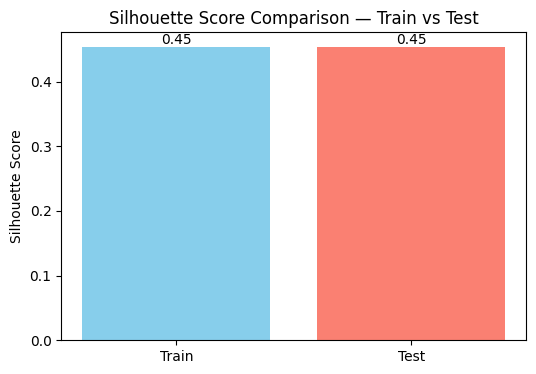

In [32]:
# Silhouette Score Comparison — Train vs Test
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as plt

# Use the clusterer fitted on the full dataset to predict on train/test
train_labels = kmeans.predict(X_train)
test_labels = kmeans.predict(X_test)

train_score = silhouette_score(X_train, train_labels)
test_score = silhouette_score(X_test, test_labels)

scores = [train_score, test_score]
types = ['Train', 'Test']
plt.figure(figsize=(6,4))
bars = plt.bar(types, scores, color=['skyblue', 'salmon'])
plt.title('Silhouette Score Comparison — Train vs Test')
plt.ylabel('Silhouette Score')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height(), f'{score:.2f}', ha='center', va='bottom')
plt.show()